# Classificazione multiclasse

In questa esercitazione utilizzeremo lo stesso dataset della classificazione binaria per effettuare un task differente: una classificazione multiclasse sulla variabile `dzgroup`.

In [1]:
import numpy as np
import pandas as pd
from sklearn._config import set_config

set_config(transform_output = 'pandas')

In [2]:
dd = pd.read_csv("data/dataset_esercitazione.csv")
dd

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc,death
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,7.000000,0
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,1.000000,1
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,0.000000,1
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,0.000000,1
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,2.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,66.07300,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,8.0,NaN,0.0,52870.0,34329.3125,...,1.099854,131.0,7.459961,188.0,21.0,NaN,NaN,0.0,0.000000,0
9101,55.15399,female,Coma,Coma,1,11.0,NaN,41.0,35377.0,23558.5000,...,5.899414,135.0,7.289062,190.0,49.0,0.0,NaN,0.0,0.000000,0
9102,70.38196,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,0.0,46564.0,31409.0156,...,2.699707,139.0,7.379883,189.0,60.0,3900.0,NaN,NaN,2.525391,0
9103,47.01999,male,MOSF w/Malig,ARF/MOSF,1,13.0,NaN,0.0,58439.0,NaN,...,3.500000,135.0,7.469727,246.0,55.0,NaN,NaN,0.0,0.000000,1


In [3]:
# quante unità ci sono per ogni classe di dzgroup?
dd["dzgroup"].value_counts()

dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64

Ci sono 8 classi di dzgroup, la più numerosa è la classe "ARF/MOSF w/Sepsis" 

## Preprocessing

1. Rimozione colonne sparse;
2. Rimozione fattori prognostici connessi alla risposta;
3. Splitting;
4. Imputazione dati mancanti;
5. Encoding (in questo caso anche della risposta);
6. Analisi di correlazione con y e tra le feature;
7. Feature Selection;
8. Adattamento di alcuni modelli di classificazione multiclasse;

In [4]:
dd.isna().mean().sort_values(ascending = False)

adlp        0.619550
urine       0.533992
glucose     0.494234
bun         0.477979
totmcst     0.381658
alb         0.370346
income      0.327512
adls        0.314882
bili        0.285667
pafi        0.255354
ph          0.250851
prg2m       0.181109
edu         0.179462
prg6m       0.179352
totcst      0.097529
wblc        0.023284
charges     0.018891
avtisst     0.009006
crea        0.007359
race        0.004613
dnr         0.003295
dnrday      0.003295
sps         0.000110
surv2m      0.000110
scoma       0.000110
resp        0.000110
temp        0.000110
sod         0.000110
hrt         0.000110
meanbp      0.000110
aps         0.000110
surv6m      0.000110
age         0.000000
sex         0.000000
dzgroup     0.000000
num.co      0.000000
dzclass     0.000000
hday        0.000000
diabetes    0.000000
ca          0.000000
dementia    0.000000
adlsc       0.000000
death       0.000000
dtype: float64

In [5]:
col_sparse = dd.columns[dd.isna().mean() > 0.5]
col_sparse

Index(['urine', 'adlp'], dtype='object')

In [6]:
dd = dd.drop(columns = col_sparse)

In [7]:
dd.shape

(9105, 41)

Ricordiamo le variabili prognostiche:
- `aps` e `sps`;
- `dzclass` e `death`

In [8]:
diag_to_drop = ['aps', 'sps', 'dzclass', 'death']
dd = dd.drop(columns = diag_to_drop)

In [9]:
dd.shape

(9105, 37)

In [10]:
from sklearn.model_selection import train_test_split
X = dd.drop(columns = 'dzgroup')
y = dd['dzgroup']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size = 0.05, random_state = 42, stratify = y)

In [11]:
from sklearn.impute import SimpleImputer
num_cols = X_tr.select_dtypes(include = 'number').columns
cat_cols = X_tr.select_dtypes(exclude = 'number').columns

imp1 = SimpleImputer(strategy = 'median')
imp2 = SimpleImputer(strategy = 'constant', fill_value = 'missing')

In [12]:
X_tr[num_cols] = imp1.fit_transform(X_tr[num_cols])
X_tr[cat_cols] = imp2.fit_transform(X_tr[cat_cols])

X_te[num_cols] = imp1.transform(X_te[num_cols])
X_te[cat_cols] = imp2.transform(X_te[cat_cols])

In [13]:
X_tr[cat_cols].apply(lambda x: x.unique())

sex                                          [male, female]
income     [missing, $25-$50k, $11-$25k, under $11k, >$50k]
race        [white, hispanic, black, asian, other, missing]
ca                                    [yes, no, metastatic]
dnr       [no dnr, dnr after sadm, dnr before sadm, miss...
dtype: object

In [14]:
ord_cols = ['income', 'ca']
ord_cats = [['missing', 'under $11k', '$11-$25k', '$25-$50k', '>$50k'], ['no', 'yes', 'metastatic']]

In [15]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
oe = OrdinalEncoder()
oe1 = OrdinalEncoder(categories = ord_cats)
le = LabelEncoder()

In [16]:
cat_cols = cat_cols.drop(ord_cols)

In [17]:
X_tr[cat_cols] = oe.fit_transform(X_tr[cat_cols])
X_tr[ord_cols] = oe1.fit_transform(X_tr[ord_cols])
y_tr = le.fit_transform(y_tr)

X_te[cat_cols] = oe.transform(X_te[cat_cols])
X_te[ord_cols] = oe1.transform(X_te[ord_cols])
y_te = le.transform(y_te)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

### Analisi di correlazione

In [19]:
# Classe di X_tr e di y_tr
type(X_tr), type(y_tr)

(pandas.core.frame.DataFrame, numpy.ndarray)

In [20]:
y_tr = pd.Series(y_tr)
y_te = pd.Series(y_te)

In [21]:
soglia = 0.01

col_to_remove = (
    X_tr.corrwith(y_tr)
    .abs()
    .sort_values(ascending = False)
    .loc[lambda x: x < soglia]
    .index
)

col_to_remove

Index(['crea', 'prg2m', 'ph', 'prg6m', 'charges', 'dementia', 'age', 'dnr',
       'num.co', 'hday', 'diabetes', 'adls', 'bili', 'pafi', 'totmcst',
       'totcst', 'glucose', 'sex', 'bun', 'surv6m', 'adlsc', 'avtisst', 'ca',
       'edu', 'alb', 'surv2m', 'race'],
      dtype='object')

In [22]:
len(col_to_remove)

27

In [23]:
X_tr = X_tr.drop(columns = col_to_remove)
X_te = X_te.drop(columns = col_to_remove)

In [24]:
soglia = 0.8

coppie = (
    X_tr.corr()
    .abs()
    .map(lambda x: x > soglia)
    .unstack()
    .reset_index()
)

coppie.columns = ['var1', 'var2', 'high_corr']
coppie = coppie.loc[lambda x: x['high_corr'] & (x['var1'] < x['var2'])]
coppie

,var1,var2,high_corr


Non ci sono variabili multicollineari.

### Feature selection

In [25]:
from sklearn.feature_selection import SelectKBest, f_classif
skb = SelectKBest(score_func=f_classif, k = "all")
skb.fit(X_tr, y_tr)
skb.pvalues_

array([5.50991897e-027, 0.00000000e+000, 9.50887121e-182, 8.56808190e-019,
       1.37406888e-032, 9.58667311e-036, 3.56372424e-005, 8.06396556e-083,
       3.51537198e-021])

In [26]:
sel = SelectKBest(score_func=f_classif, k = 8)
X_tr_sel = sel.fit_transform(X_tr, y_tr)
X_te_sel = sel.transform(X_te)

## Classificatore multiclasse con tuning iperparametri

In [27]:
# RandomForestClassifier con tuning di iperparametri:
# criterion : "gini", "logloss"
# min_samples_split: [2, 5, 10]
# max_features: "sqrt", 5

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42)
param_grid = {
    # "n_estimators": [100, 200],
    "criterion" : ["gini", "log_loss"],
    "min_samples_split" : [2, 5, 10],
    # "min_samples_leaf" : [1, 2, 4, 10],
    "max_features": ["sqrt", 5]
}

grid_rf = GridSearchCV(estimator = rf,
                       param_grid= param_grid, 
                       cv = 5, 
                       n_jobs=1)

grid_rf.fit(X_tr_sel, y_tr)
print("Miglior modello:", grid_rf.best_params_)

Miglior modello: {'criterion': 'gini', 'max_features': 'sqrt', 'min_samples_split': 10}


In [28]:
best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_te_sel)

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_te, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.72      0.57       176
           1       0.32      0.43      0.37        69
           2       0.11      0.04      0.06        48
           3       1.00      0.08      0.15        25
           4       0.20      0.04      0.06        26
           5       0.47      0.47      0.47        30
           6       0.45      0.28      0.35        46
           7       0.54      0.19      0.29        36

    accuracy                           0.43       456
   macro avg       0.44      0.28      0.29       456
weighted avg       0.43      0.43      0.38       456



## Curve ROC e AUC di ogni classe, ciascuna valutata in modalità one-vs-rest

Per poter eseguire questo task, ci appoggiamo alla guida di scikit-learn, in particolare alla sezione **Multiclass Receiver Operating Characteristic (ROC)**. 

Per rappresentare invece tutte le singole curve ROC in modalità One-vs-Rest, possiamo fare la seguente rappresentazione:

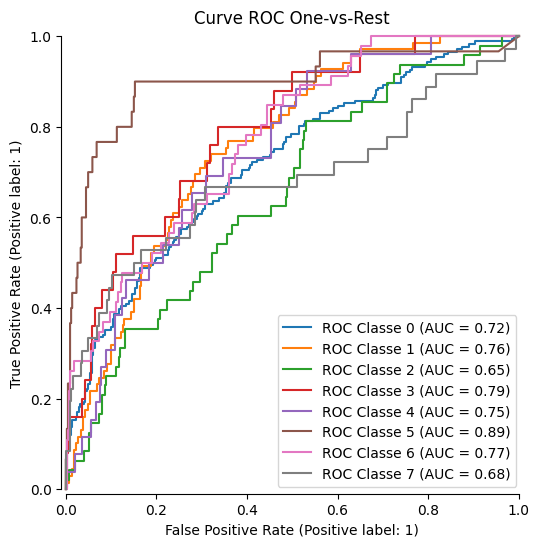

In [30]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# 1. Binarizza le etichette reali (One-Hot Encoding)
y_onehot = LabelBinarizer().fit_transform(y_te)

# 2. Ottieni le probabilità predette dal modello
y_score = best_rf.predict_proba(X_te_sel)

# 3. Disegna il grafico con un semplice ciclo
fig, ax = plt.subplots(figsize=(8, 6))
for i, classe in enumerate(best_rf.classes_):
    RocCurveDisplay.from_predictions(
        y_onehot[:, i], 
        y_score[:, i], 
        name=f"ROC Classe {classe}", 
        ax=ax,
        despine = True
    )

plt.title("Curve ROC One-vs-Rest")
plt.legend()
plt.show()


In [31]:
# Calcola il Macro-AUC e Micro-AUC in un'unica riga senza impazzire
macro_auc = roc_auc_score(y_te, y_score, multi_class="ovr", average="macro")
micro_auc = roc_auc_score(y_te, y_score, multi_class="ovr", average="micro")

print(f"Macro AUC:", macro_auc), print("Micro AUC:", micro_auc)


Macro AUC: 0.75079290982546
Micro AUC: 0.820356813085345


(None, None)